<a href="https://colab.research.google.com/github/shrutib32005-collab/Activity1-Geographical-Location-Clustering/blob/main/Activity1_Geographical_location_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Select the first 40 records
df = df.head(40)

print("Dataset Shape:", df.shape)
df.head(10)

In [ ]:
import pandas as pd

url = "https://gist.githubusercontent.com/MSushmaReddy/af8603899c50e3b2381b009e6011c725/raw/Places_in_India.csv"

df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
df.head(10)

Dataset Shape: (180, 7)


,city,state,population,latitude,longitude,avg_temperature_celsius,avg_humidity_percent
0,Mumbai,Maharashtra,12442373,19.0760,72.8777,28,75
1,Delhi,Delhi,11007835,28.7041,77.1025,25,60
2,Bangalore,Karnataka,8443675,12.9716,77.5946,24,65
3,Hyderabad,Telangana,6809970,17.3850,78.4867,27,70
4,Ahmedabad,Gujarat,5570585,23.0225,72.5714,32,55
5,Chennai,Tamil Nadu,4681087,13.0827,80.2707,30,80
6,Kolkata,West Bengal,4486679,22.5726,88.3639,29,80
7,Surat,Gujarat,4467797,21.1702,72.8311,31,65
8,Pune,Maharashtra,3124458,18.5204,73.8567,26,70
9,Jaipur,Rajasthan,3046163,26.9124,75.7873,33,50


In [ ]:
# Select the first 40 records
df = df.head(40)

print("Dataset Shape:", df.shape)
df.head(10)

Dataset Shape: (40, 7)


,city,state,population,latitude,longitude,avg_temperature_celsius,avg_humidity_percent
0,Mumbai,Maharashtra,12442373,19.0760,72.8777,28,75
1,Delhi,Delhi,11007835,28.7041,77.1025,25,60
2,Bangalore,Karnataka,8443675,12.9716,77.5946,24,65
3,Hyderabad,Telangana,6809970,17.3850,78.4867,27,70
4,Ahmedabad,Gujarat,5570585,23.0225,72.5714,32,55
5,Chennai,Tamil Nadu,4681087,13.0827,80.2707,30,80
6,Kolkata,West Bengal,4486679,22.5726,88.3639,29,80
7,Surat,Gujarat,4467797,21.1702,72.8311,31,65
8,Pune,Maharashtra,3124458,18.5204,73.8567,26,70
9,Jaipur,Rajasthan,3046163,26.9124,75.7873,33,50


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Select features for clustering
features = [
    "latitude",
    "longitude",
    "population",
    "avg_temperature_celsius",
    "avg_humidity_percent"
]

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

X = df[features]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

# Calculate silhouette score
score = silhouette_score(X_scaled, df["Cluster"])

print("Number of Clusters:", k)
print("Silhouette Score:", round(score, 4))

# Display clustered data
df[["city", "state", "Cluster"]].head(10)

Number of Clusters: 3
Silhouette Score: 0.2809


,city,state,Cluster
0,Mumbai,Maharashtra,2
1,Delhi,Delhi,1
2,Bangalore,Karnataka,2
3,Hyderabad,Telangana,2
4,Ahmedabad,Gujarat,0
5,Chennai,Tamil Nadu,2
6,Kolkata,West Bengal,1
7,Surat,Gujarat,0
8,Pune,Maharashtra,2
9,Jaipur,Rajasthan,0


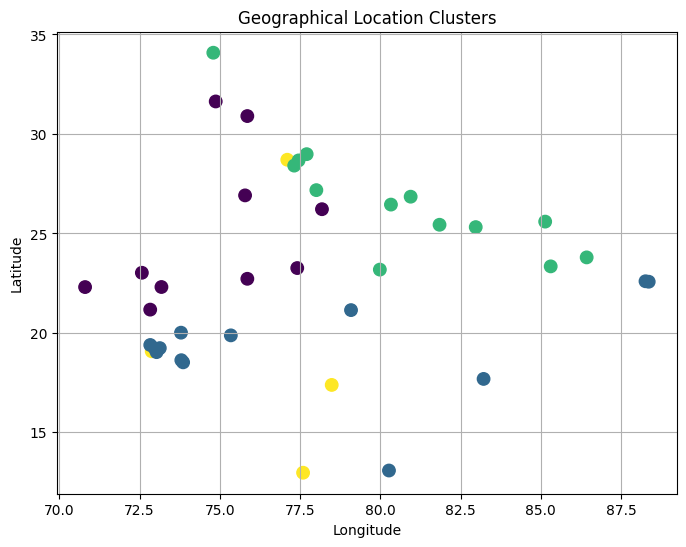

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["Cluster"],
    s=80
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Location Clusters")
plt.grid(True)

plt.show()